In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
customers = pd.read_csv("../ecommerce_dataset/users.csv")

orders = pd.read_csv("../ecommerce_dataset/orders.csv")

In [3]:
customer_data = orders.merge(
    customers,
    on="user_id",
    how="left"
)

In [4]:
customer_features = customer_data.groupby("user_id").agg({

    "total_amount": "sum",

    "order_id": "count"

}).reset_index()

In [5]:
customer_features.columns = [
    "user_id",
    "total_spent",
    "num_orders"
]

In [6]:
customer_features.head()

,user_id,total_spent,num_orders
0,U000001,1392.89,1
1,U000002,1808.15,4
2,U000003,1153.01,3
3,U000004,7620.84,3
4,U000005,12.66,1


In [7]:
scaler = StandardScaler()

X = scaler.fit_transform(
    customer_features[
        [
            "total_spent",
            "num_orders"
        ]
    ]
)

In [8]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

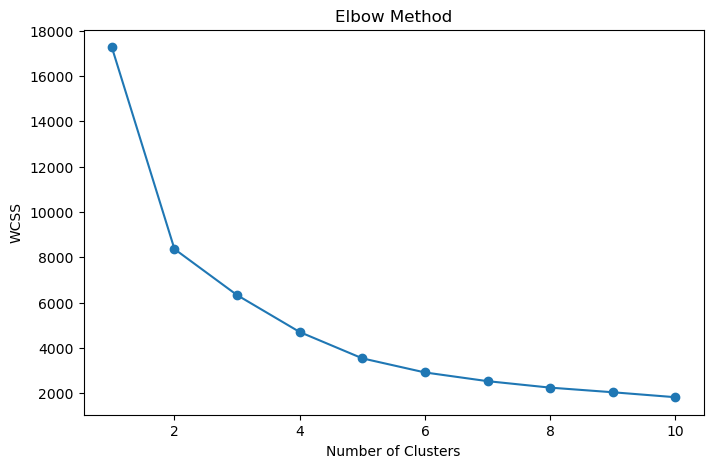

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_features["cluster"] = kmeans.fit_predict(X)
customer_features.head()

,user_id,total_spent,num_orders,cluster
0,U000001,1392.89,1,1
1,U000002,1808.15,4,3
2,U000003,1153.01,3,2
3,U000004,7620.84,3,0
4,U000005,12.66,1,1


In [11]:
customer_features.groupby("cluster").agg({

    "total_spent": "mean",

    "num_orders": "mean",

    "user_id": "count"

}).round(2)

,total_spent,num_orders,user_id
cluster,,,
0,4387.79,3.28,955
1,500.33,1.00,2674
2,1080.48,2.35,3897
3,1965.55,4.55,1109


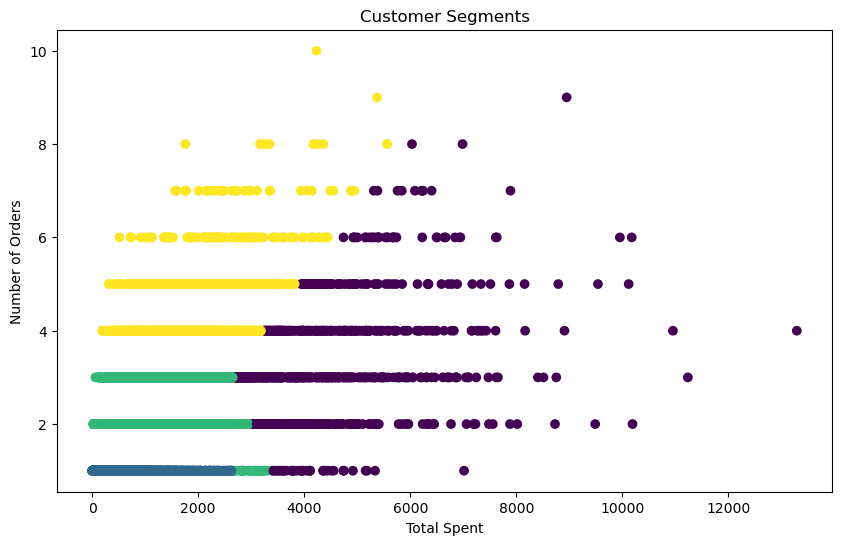

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    customer_features["total_spent"],
    customer_features["num_orders"],
    c=customer_features["cluster"]
)

plt.xlabel("Total Spent")
plt.ylabel("Number of Orders")
plt.title("Customer Segments")

plt.show()

In [13]:
customer_features.groupby("cluster").agg({

    "total_spent":"mean",

    "num_orders":"mean",

    "user_id":"count"

}).round(2)

,total_spent,num_orders,user_id
cluster,,,
0,4387.79,3.28,955
1,500.33,1.00,2674
2,1080.48,2.35,3897
3,1965.55,4.55,1109
